In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load the dataset.
data_set = Path("/Users/bs01381/Documents/DataScience/house-price-prediction/data/USA_Housing.csv")

df = pd.read_csv(data_set)
print(f"Shape: {df.shape}")

Shape: (5000, 7)


In [3]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [4]:
address = df["Address"]
df_without_address = df.drop(columns=["Address"])

df_without_address.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


# Linear Regression

In [5]:
# Split the dataset into features and target variable

X = df_without_address.drop('Price', axis=1)  # features
y = df_without_address['Price'] # target

In [6]:
# Split the dataset into training and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Train mean price: ${y_train.mean():,.0f}")
print(f"Test mean price: ${y_test.mean():,.0f}")

Training: 4000
Test: 1000
Train mean price: $1,229,577
Test mean price: $1,242,055


In [7]:
# Scale the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Train a linear regression model

from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# Print the coefficients and intercept of the linear regression model

for feature, coef in zip(X.columns, model_linear.coef_):
    print(f"{feature} (m): {coef:,.2f}")

intercept = model_linear.intercept_
print(f"Intercept (c): {intercept:,.2f}")

Avg. Area Income (m): 231,741.88
Avg. Area House Age (m): 163,580.78
Avg. Area Number of Rooms (m): 120,724.77
Avg. Area Number of Bedrooms (m): 2,992.45
Area Population (m): 152,235.90
Intercept (c): 1,229,576.99


In [10]:
# Make predictions on the test set

y_test_pred_linear = model_linear.predict(X_test_scaled)

print("First 5 predictions (sklearn):")
for i in range(5):
    print(f"Actual: ${y_test.iloc[i]:,.0f}, Predicted: ${y_test_pred_linear[i]:,.0f}")

First 5 predictions (sklearn):
Actual: $1,339,096, Predicted: $1,308,588
Actual: $1,251,794, Predicted: $1,237,037
Actual: $1,340,095, Predicted: $1,243,429
Actual: $1,431,508, Predicted: $1,228,900
Actual: $1,042,374, Predicted: $1,063,321


In [11]:
# Evaluate the model's performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_mae_sklearn = mean_absolute_error(y_test, y_test_pred_linear)
lr_mse_sklearn = mean_squared_error(y_test, y_test_pred_linear)
lr_rmse_sklearn = np.sqrt(lr_mse_sklearn)
lr_r2_sklearn = r2_score(y_test, y_test_pred_linear)

print(f"MAE: {lr_mae_sklearn:,.2f}")
print(f"MSE: {lr_mse_sklearn:,.2f}")
print(f"RMSE: {lr_rmse_sklearn:,.2f}")
print(f"R² Score: {lr_r2_sklearn:.4f}")

MAE: 80,879.10
MSE: 10,089,009,300.89
RMSE: 100,444.06
R² Score: 0.9180


## Ridge

In [12]:
# Evaluate the Ridge regression model

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

ridge_grid.fit(X_train_scaled, y_train)
best_alpha_ridge = ridge_grid.best_params_['alpha']

print("Ridge Regression - Best Parameters:")
print(f"  Alpha: {best_alpha_ridge}")
print(f"  Best CV RMSE: {np.sqrt(-ridge_grid.best_score_):.3f}")

Ridge Regression - Best Parameters:
  Alpha: 1.0
  Best CV RMSE: 101455.957


In [13]:
# Evaluate the best Ridge model on the test set

best_ridge = Ridge(alpha=best_alpha_ridge)
best_ridge.fit(X_train_scaled, y_train)

y_test_pred_best_ridge = best_ridge.predict(X_test_scaled)

ridge_mae_sklearn = mean_absolute_error(y_test, y_test_pred_best_ridge)
ridge_mse_sklearn = mean_squared_error(y_test, y_test_pred_best_ridge)
ridge_rmse_sklearn = np.sqrt(ridge_mse_sklearn)
ridge_r2_sklearn = r2_score(y_test, y_test_pred_best_ridge)

print(f"MAE: {ridge_mae_sklearn:,.2f}")
print(f"MSE: {ridge_mse_sklearn:,.2f}")
print(f"RMSE: {ridge_rmse_sklearn:,.2f}")
print(f"R² Score: {ridge_r2_sklearn:.4f}")

print("\nFirst 5 predictions:")
for i in range(5):
    print(f"Actual: ${y_test.iloc[i]:,.0f}, Predicted: ${y_test_pred_best_ridge[i]:,.0f}")


MAE: 80,877.76
MSE: 10,089,003,188.71
RMSE: 100,444.03
R² Score: 0.9180

First 5 predictions:
Actual: $1,339,096, Predicted: $1,308,560
Actual: $1,251,794, Predicted: $1,237,022
Actual: $1,340,095, Predicted: $1,243,397
Actual: $1,431,508, Predicted: $1,228,898
Actual: $1,042,374, Predicted: $1,063,344


# Lasso

In [14]:
# Evaluate the Lasso regression model

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring='neg_mean_squared_error'
)

lasso_grid.fit(X_train_scaled, y_train)
best_alpha_lasso = lasso_grid.best_params_['alpha']

print("\nLasso Regression - Best Parameters:")
print(f"  Alpha: {best_alpha_lasso}")
print(f"  Best CV RMSE: {np.sqrt(-lasso_grid.best_score_):.3f}")




Lasso Regression - Best Parameters:
  Alpha: 10.0
  Best CV RMSE: 101456.025


In [15]:
# Evaluate the best Lasso model on the test set

best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

y_test_pred_best_lasso = best_lasso.predict(X_test_scaled)

lasso_mae_sklearn = mean_absolute_error(y_test, y_test_pred_best_lasso)
lasso_mse_sklearn = mean_squared_error(y_test, y_test_pred_best_lasso)
lasso_rmse_sklearn = np.sqrt(lasso_mse_sklearn)
lasso_r2_sklearn = r2_score(y_test, y_test_pred_best_lasso)

print(f"MAE: {lasso_mae_sklearn:,.2f}")
print(f"MSE: {lasso_mse_sklearn:,.2f}")
print(f"RMSE: {lasso_rmse_sklearn:,.2f}")
print(f"R² Score: {lasso_r2_sklearn:.4f}")

print("\nFirst 5 predictions:")
for i in range(5):
    print(f"Actual: ${y_test.iloc[i]:,.0f}, Predicted: ${y_test_pred_best_lasso[i]:,.0f}")


MAE: 80,878.71
MSE: 10,088,940,217.89
RMSE: 100,443.72
R² Score: 0.9180

First 5 predictions:
Actual: $1,339,096, Predicted: $1,308,582
Actual: $1,251,794, Predicted: $1,237,037
Actual: $1,340,095, Predicted: $1,243,442
Actual: $1,431,508, Predicted: $1,228,903
Actual: $1,042,374, Predicted: $1,063,339


# Polynomial Regression

In [16]:
from sklearn.preprocessing import PolynomialFeatures

degrees_test = range(1, 15)
train_mse = []
test_mse = []

for degree in degrees_test:
    poly = PolynomialFeatures(degree=degree)
    poly.fit(X_train_scaled)

    X_train_poly = poly.transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_mse.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_mse.append(mean_squared_error(y_test, model.predict(X_test_poly)))

#get the best degree based on test MSE
best_degree = degrees_test[np.argmin(test_mse)]
print(f"Best Degree: {best_degree}")

Best Degree: 1


In [17]:
# Retrain with best degree and evaluate on test set

poly = PolynomialFeatures(degree=best_degree)
poly.fit(X_train_scaled)
X_train_poly = poly.transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_test_pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_test_pred_poly)
mse_poly = mean_squared_error(y_test, y_test_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"MAE: {mae_poly:,.2f}")
print(f"MSE: {mse_poly:,.2f}")
print(f"RMSE: {rmse_poly:,.2f}")
print(f"R² Score: {r2_poly:.4f}")

print("\nFirst 5 predictions:")
for i in range(5):
    print(f"Actual: ${y_test.iloc[i]:,.0f}, Predicted: ${y_test_pred_poly[i]:,.0f}")

MAE: 80,879.10
MSE: 10,089,009,300.89
RMSE: 100,444.06
R² Score: 0.9180

First 5 predictions:
Actual: $1,339,096, Predicted: $1,308,588
Actual: $1,251,794, Predicted: $1,237,037
Actual: $1,340,095, Predicted: $1,243,429
Actual: $1,431,508, Predicted: $1,228,900
Actual: $1,042,374, Predicted: $1,063,321


# KNN

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 31)
train_mse_knn = []
test_mse_knn = []

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    y_train_pred_knn = knn_model.predict(X_train_scaled)
    y_test_pred_knn = knn_model.predict(X_test_scaled)
    
    train_mse_knn.append(mean_squared_error(y_train, y_train_pred_knn))
    test_mse_knn.append(mean_squared_error(y_test, y_test_pred_knn))

knn_best_k = k_values[np.argmin(test_mse_knn)]
print(f"Best K: {knn_best_k}")
print(f"Best Test MSE: {min(test_mse_knn):,.0f}")

Best K: 9
Best Test MSE: 15,311,227,372


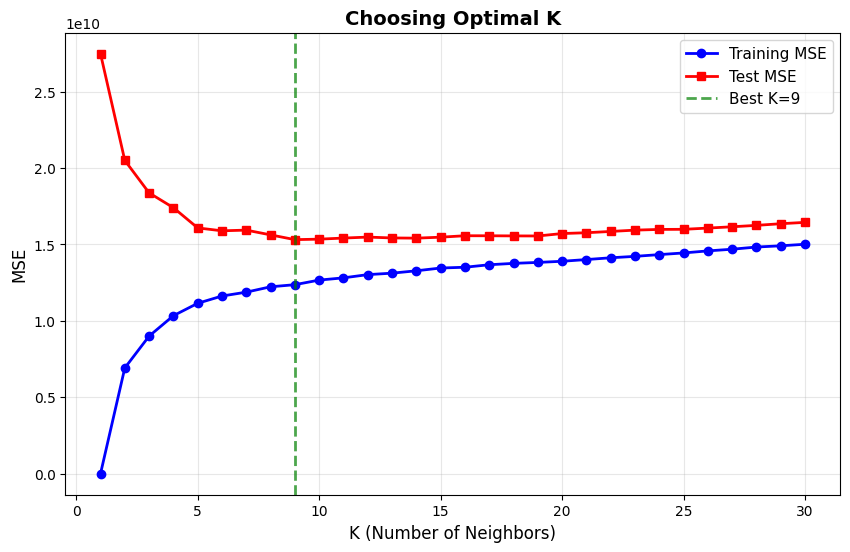

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_mse_knn, 'bo-', label='Training MSE', linewidth=2, markersize=6)
plt.plot(k_values, test_mse_knn, 'rs-', label='Test MSE', linewidth=2, markersize=6)
plt.axvline(knn_best_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best K={knn_best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Train the final KNN model with the best K and evaluate on the test set

best_model_knn = KNeighborsRegressor(n_neighbors=knn_best_k)

best_model_knn.fit(X_train_scaled, y_train)

y_test_pred_knn = best_model_knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_test_pred_knn)
mse_knn = mean_squared_error(y_test, y_test_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_test_pred_knn)

print(f"MAE: {mae_knn:,.2f}")
print(f"MSE: {mse_knn:,.2f}")
print(f"RMSE: {rmse_knn:,.2f}")
print(f"R² Score: {r2_knn:.4f}")

print("\nFirst 5 predictions:")
for i in range(5):
    print(f"Actual: ${y_test.iloc[i]:,.0f}, Predicted: ${y_test_pred_knn[i]:,.0f}")

MAE: 98,589.58
MSE: 15,311,227,371.92
RMSE: 123,738.54
R² Score: 0.8756

First 5 predictions:
Actual: $1,339,096, Predicted: $1,293,468
Actual: $1,251,794, Predicted: $1,259,887
Actual: $1,340,095, Predicted: $1,221,573
Actual: $1,431,508, Predicted: $1,186,011
Actual: $1,042,374, Predicted: $1,021,477


# Model comparison table

In [21]:
# Create a table comparing all models (Model, Train R², Test R², Test MSE), sorted by Test R²

models_to_compare = [
    ("Linear Regression", model_linear, X_train_scaled, X_test_scaled),
    ("Ridge Regression", best_ridge, X_train_scaled, X_test_scaled),
    ("Lasso Regression", best_lasso, X_train_scaled, X_test_scaled),
    (f"Polynomial Regression (Degree {best_degree})", model_poly, X_train_poly, X_test_poly),
    (f"KNN Regression (K={knn_best_k})", best_model_knn, X_train_scaled, X_test_scaled),
]

comparison_rows = []
for model_name, model_obj, X_tr, X_te in models_to_compare:
    y_train_pred = model_obj.predict(X_tr)
    y_test_pred = model_obj.predict(X_te)

    comparison_rows.append({
        "Model": model_name,
        "Train R²": r2_score(y_train, y_train_pred),
        "Test R²": r2_score(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(by="Test R²", ascending=False)
    .reset_index(drop=True)
)

model_comparison




,Model,Train R²,Test R²,Test MAE,Test MSE,Test RMSE
0,Lasso Regression,0.917979,0.917998,80878.705153,1.008894e+10,100443.716667
1,Ridge Regression,0.917979,0.917997,80877.763040,1.008900e+10,100444.030130
2,Linear Regression,0.917979,0.917997,80879.097235,1.008901e+10,100444.060556
3,Polynomial Regression (Degree 1),0.917979,0.917997,80879.097235,1.008901e+10,100444.060556
4,KNN Regression (K=9),0.901118,0.875551,98589.581989,1.531123e+10,123738.544407


# Select best model

In [22]:
# Choose the best model based on Test R², explain performance, and check overfitting

best_model = model_comparison.iloc[0]
best_model_name = best_model["Model"]
best_model_train_r2 = best_model["Train R²"]
best_model_test_r2 = best_model["Test R²"]
best_model_test_mse = best_model["Test MSE"]

# Generalization gap: positive means training fit is better than test fit
r2_gap = best_model_train_r2 - best_model_test_r2

# Quick EDA signal: strongest linear correlations with Price
corr_to_price = (
    df_without_address.corr(numeric_only=True)["Price"]
    .drop("Price")
    .abs()
    .sort_values(ascending=False)
)
top_features = corr_to_price.head(3)

print(f"Best Model: {best_model_name}")
print(f"Train R²: {best_model_train_r2:.4f}")
print(f"Test R²:  {best_model_test_r2:.4f}")
print(f"Test MSE: {best_model_test_mse:,.2f}")
print(f"R² Gap (Train - Test): {r2_gap:.4f}")

if r2_gap > 0.03:
    fit_msg = "Potential overfitting: training performance is noticeably higher than test performance."
elif r2_gap < -0.03:
    fit_msg = "Potential underfitting or data split variance: test performance is higher than training performance."
else:
    fit_msg = "Good generalization: train and test performance are closely aligned."

print("\nOverfitting Check:")
print(fit_msg)

print("\nEDA Connection:")
print("Top features most linearly related to Price (absolute correlation):")
for feature, corr_value in top_features.items():
    print(f"- {feature}: {corr_value:.3f}")

print(
    "\nInterpretation: The winning model likely performed best because the dataset has strong "
    "mostly linear relationships with Price, and your standardized features help models like "
    "Linear/Ridge/Lasso generalize well. The small train-test R² gap supports this conclusion."
)

Best Model: Lasso Regression
Train R²: 0.9180
Test R²:  0.9180
Test MSE: 10,088,940,217.89
R² Gap (Train - Test): -0.0000

Overfitting Check:
Good generalization: train and test performance are closely aligned.

EDA Connection:
Top features most linearly related to Price (absolute correlation):
- Avg. Area Income: 0.640
- Avg. Area House Age: 0.453
- Area Population: 0.409

Interpretation: The winning model likely performed best because the dataset has strong mostly linear relationships with Price, and your standardized features help models like Linear/Ridge/Lasso generalize well. The small train-test R² gap supports this conclusion.


# Save pipeline

In [ ]:

# Save the complete pipeline (scaler + best model)
import joblib
from sklearn.pipeline import Pipeline

models_dir = Path("/Users/bs01381/Documents/DataScience/house-price-prediction/models")
models_dir.mkdir(parents=True, exist_ok=True)

# Map best model name to the actual fitted sklearn estimator
best_model_name = model_comparison.iloc[0]["Model"]
print(f"Saving best model: {best_model_name}")

if best_model_name == "Linear Regression":
    estimator = model_linear
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    pipeline.named_steps["scaler"].fit(X_train)
    # Re-fit whole pipeline cleanly
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

elif best_model_name.startswith("Ridge"):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha_ridge))
    ])
    pipeline.fit(X_train, y_train)

elif best_model_name.startswith("Lasso"):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=best_alpha_lasso, max_iter=10000))
    ])
    pipeline.fit(X_train, y_train)

elif best_model_name.startswith("Polynomial"):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=best_degree)),
        ("model", LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

else:  # KNN
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=knn_best_k))
    ])
    pipeline.fit(X_train, y_train)

pipeline_filename = models_dir / "best_model.pkl"
joblib.dump(pipeline, pipeline_filename)
print(f"Pipeline saved as {pipeline_filename}")

# Verify pipeline works
import numpy as np
sample = X_train.iloc[[0]]
pred = pipeline.predict(sample)
print(f"Pipeline verification - sample prediction: ${pred[0]:,.0f}")


Pipeline saved as /Users/bs01381/Documents/DataScience/house-price-prediction/models/best_model.pkl
